In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
df=pd.read_csv('/content/drive/MyDrive/DATASETS/preprocessing_dataset.csv')

In [15]:
df1=df.copy()

In [16]:
df1.isnull().sum()

,0
Name,0
Age,1
Gender,1
Salary,1
Department,0


<Axes: >

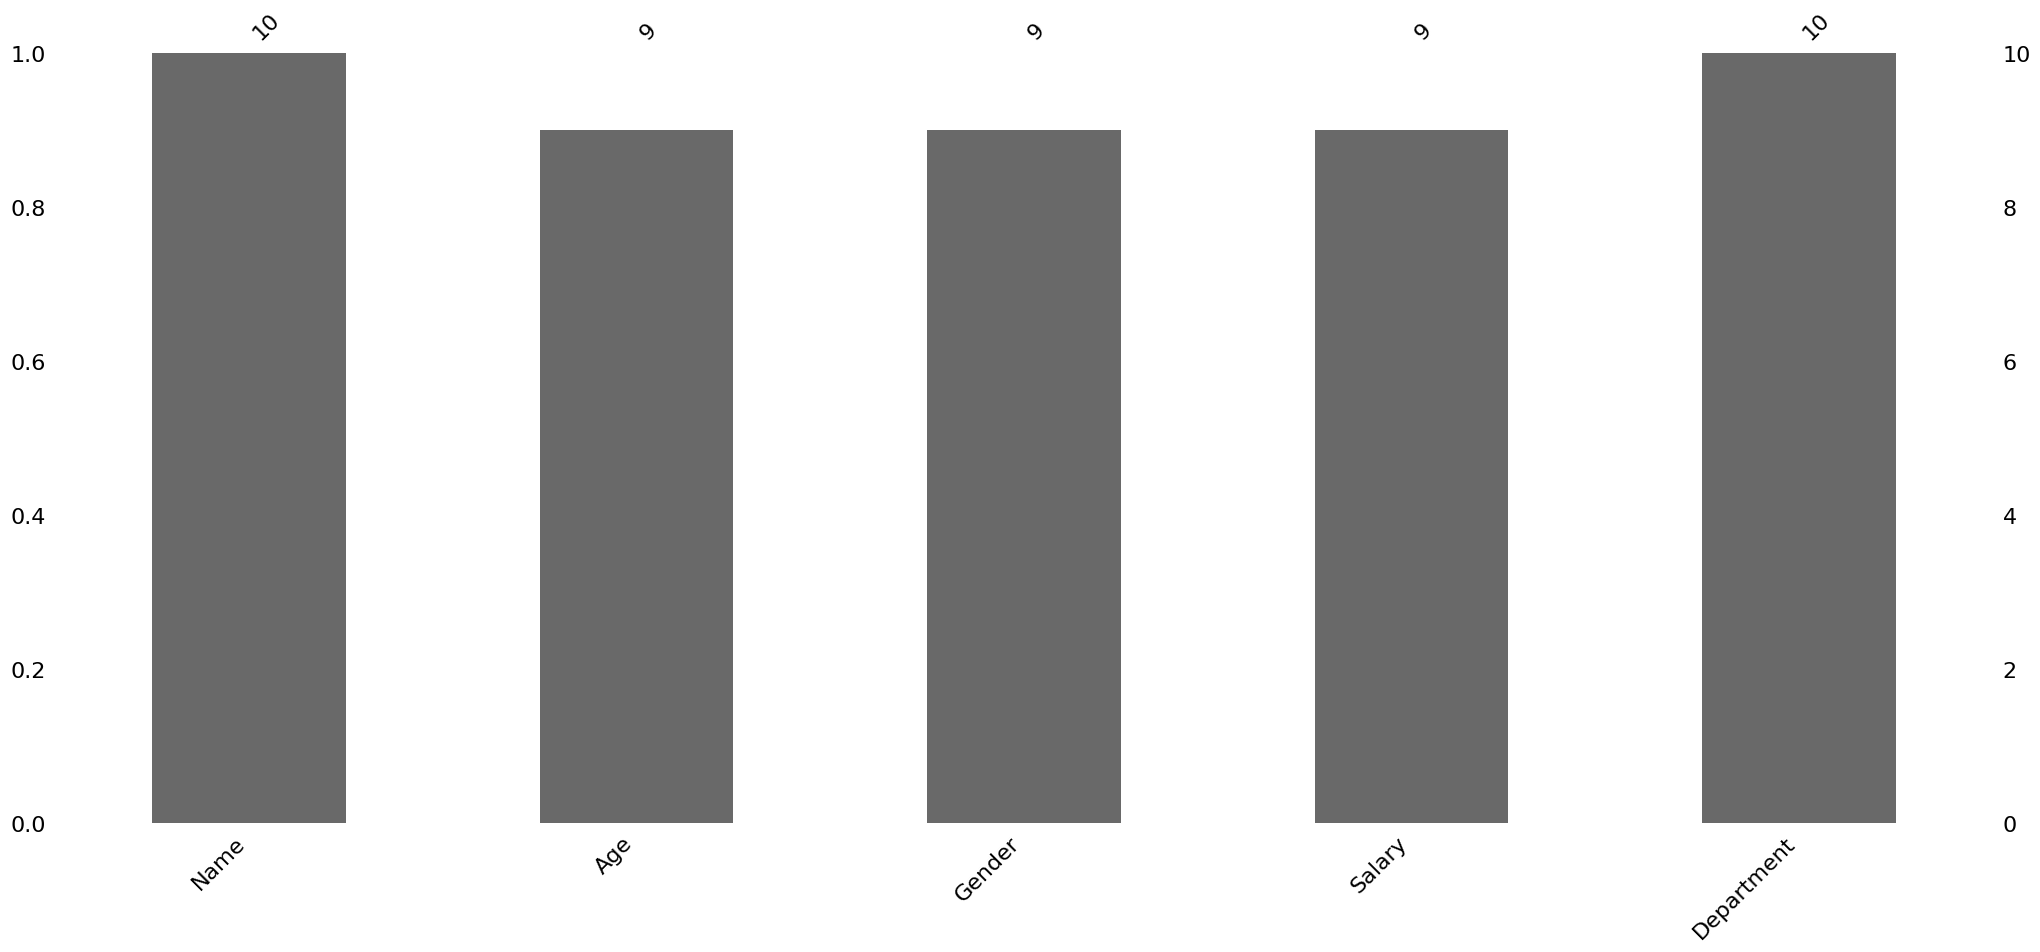

In [17]:
!pip install missingno
import missingno as msno
msno.bar(df)

<Axes: >

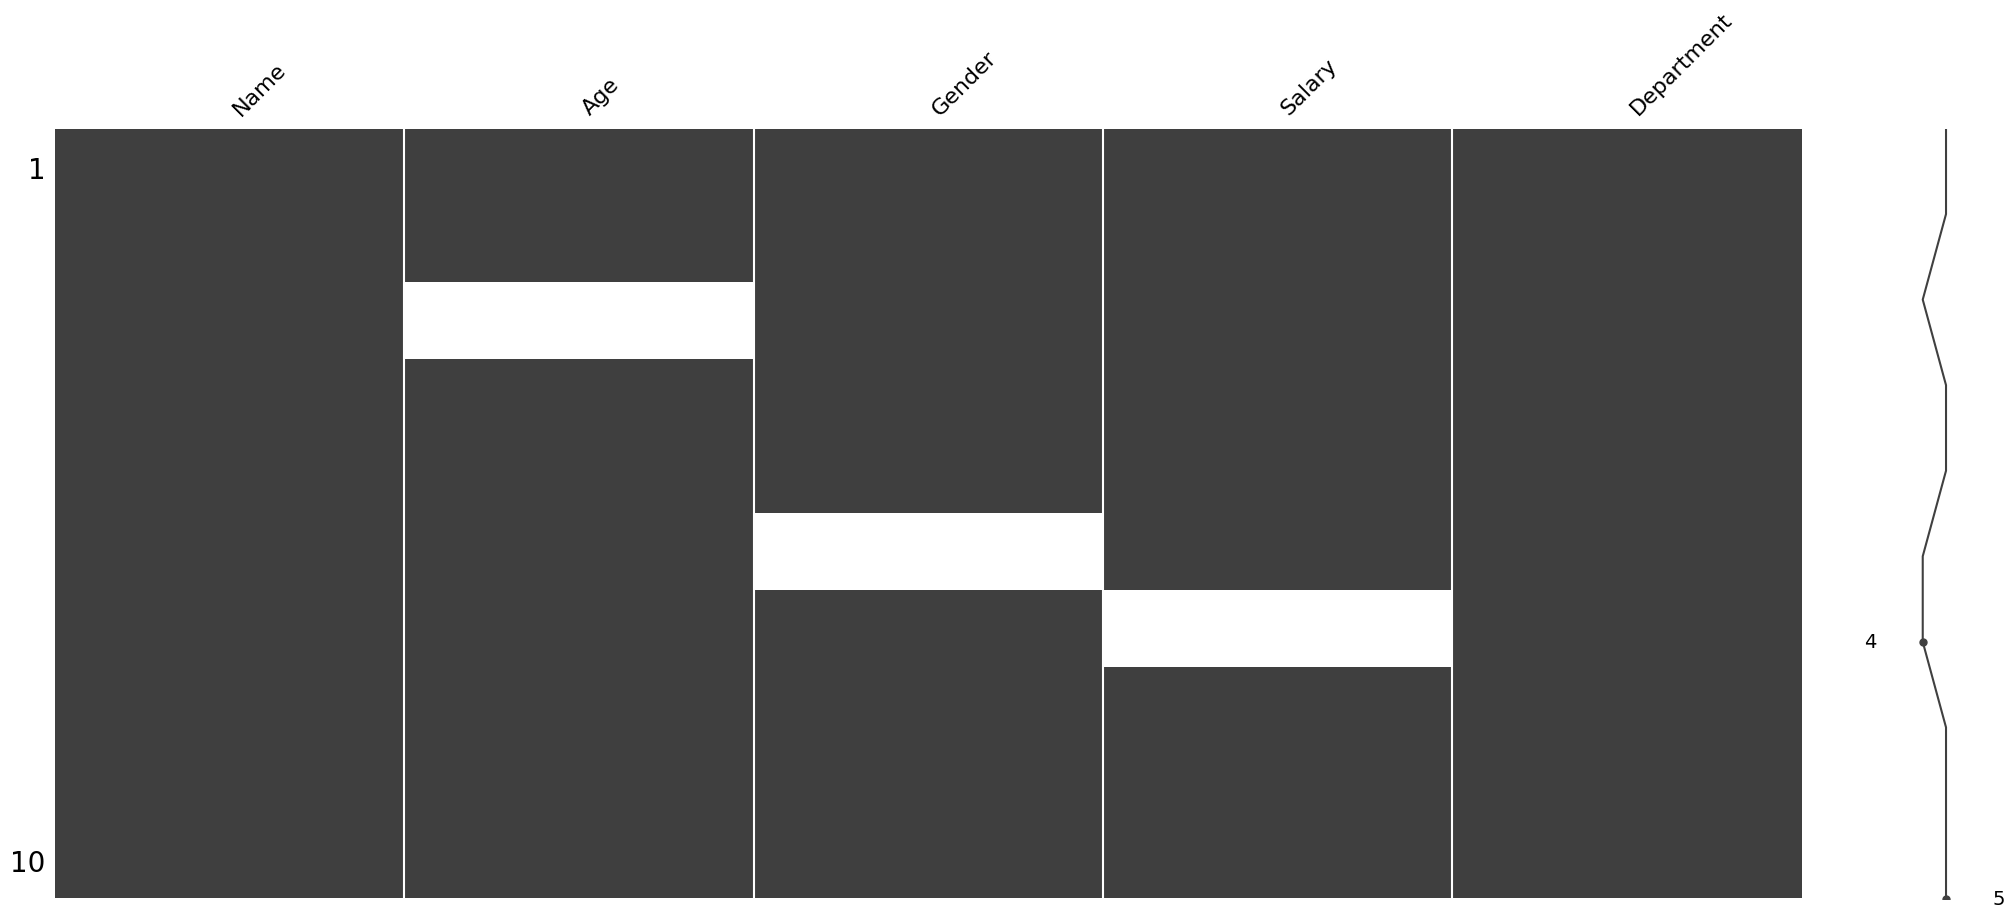

In [18]:
msno.matrix(df)

<Axes: >

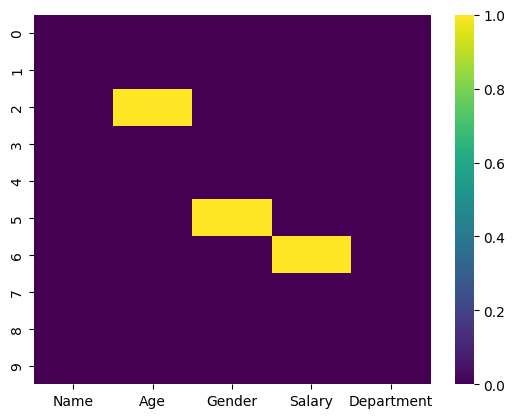

In [19]:
sns.heatmap(df.isnull(),cbar=True,cmap='viridis')

In [20]:
df ['Age'].fillna(df['Age'].mean(),inplace=True)
df ['Salary'].fillna(df['Salary'].mean(),inplace=True)
df ['Gender'].fillna(df['Gender'].mode()[0],inplace=True)

/tmp/ipykernel_5750/3485160389.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df ['Age'].fillna(df['Age'].mean(),inplace=True)
/tmp/ipykernel_5750/3485160389.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [21]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Salary,0
Department,0


In [22]:
from sklearn.impute import SimpleImputer
imp=SimpleImputer(strategy='median')
df1[['Age']]=imp.fit_transform(df1[['Age']])
df1

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,29.0,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


<Axes: ylabel='Age'>

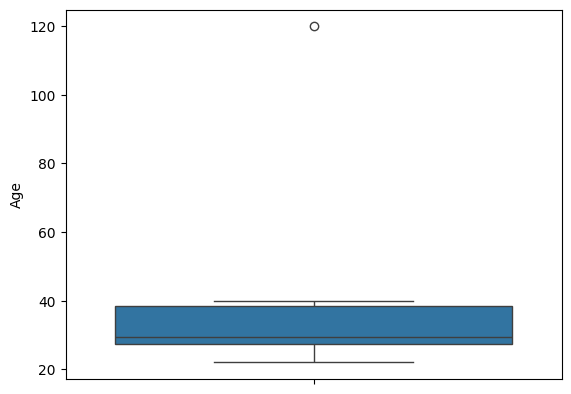

In [23]:
sns.boxplot(df['Age'])

In [24]:
Q1=df['Age'].quantile(0.25)
Q3=df['Age'].quantile(0.75)
IQR=Q3-Q1
LOWER =Q1-1.5*IQR
UPPER=Q3+1.5*IQR
d = df.loc[(df['Age'] < LOWER) | (df['Age'] > UPPER)]
print(d)

    Name    Age Gender        Salary Department
6  Grace  120.0      F  57777.777778    Finance


In [25]:

from scipy.stats import zscore
z_scores = zscore(df1['Age'])
df1[np.abs(z_scores > 2.5)]#abs - absoult score

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,NaN,Finance


In [26]:
from sklearn.ensemble import IsolationForest
iso=IsolationForest (contamination=0.1)
df['outlier']=iso.fit_predict(df1[['Age','Salary']])
df[df["outlier"]==-1]

,Name,Age,Gender,Salary,Department,outlier
6,Grace,120.0,F,57777.777778,Finance,-1


In [42]:
import pandas as pd
import numpy as np


df = pd.DataFrame({
    'Income': [1000, 2000, 5000, 10000, 1000000]
})

print("Original Dataset:\n")
print(df)

df['Log_Income'] = np.log(df['Income'])

print("\nAfter Log Transform:\n")
print(df)



Original Dataset:

    Income
0     1000
1     2000
2     5000
3    10000
4  1000000

After Log Transform:

    Income  Log_Income
0     1000    6.907755
1     2000    7.600902
2     5000    8.517193
3    10000    9.210340
4  1000000   13.815511


In [27]:
df['Age'] = np.log(df['Age'])
df

,Name,Age,Gender,Salary,Department,outlier
0,Alice,3.218876,F,50000.000000,HR,1
1,Bob,3.401197,M,60000.000000,Finance,1
2,Charlie,3.677706,M,55000.000000,IT,1
3,David,3.688879,M,58000.000000,HR,1
4,Eve,3.091042,F,52000.000000,IT,1
5,Frank,3.555348,M,61000.000000,Finance,1
6,Grace,4.787492,F,57777.777778,Finance,-1
7,Henry,3.332205,M,59000.000000,HR,1
8,Ivy,3.367296,F,63000.000000,IT,1
9,Jack,3.295837,M,62000.000000,Finance,1


In [41]:
import pandas as pd
from sklearn.preprocessing import PowerTransformer

df = pd.DataFrame({
    'Income': [1000, 2000, 5000, 10000, 1000000]
})

print("Original Dataset:\n")
print(df)

pt = PowerTransformer(method='yeo-johnson')

df['Transformed_Income'] = pt.fit_transform(df[['Income']])

print("\nAfter Power Transformation:\n")
print(df)

Original Dataset:

    Income
0     1000
1     2000
2     5000
3    10000
4  1000000

After Power Transformation:

    Income  Transformed_Income
0     1000           -1.325989
1     2000           -0.676144
2     5000           -0.007120
3    10000            0.385765
4  1000000            1.623489


In [43]:
from sklearn.preprocessing import StandardScaler

df = pd.DataFrame({
    'Income': [1000, 2000, 5000, 10000, 1000000]
})

print("Original Dataset:\n")
print(df)

scaler = StandardScaler()

df['Scaled_Income'] = scaler.fit_transform(df[['Income']])

print("\nAfter Standard Scaling:\n")
print(df)

Original Dataset:

    Income
0     1000
1     2000
2     5000
3    10000
4  1000000

After Standard Scaling:

    Income  Scaled_Income
0     1000      -0.508774
1     2000      -0.506263
2     5000      -0.498729
3    10000      -0.486173
4  1000000       1.999938


In [44]:
from sklearn.preprocessing import MinMaxScaler

df = pd.DataFrame({
    'Income': [1000, 2000, 5000, 10000, 1000000]
})

print("Original Dataset:\n")
print(df)

scaler = MinMaxScaler()

df['Scaled_Income'] = scaler.fit_transform(df[['Income']])

print("\nAfter MinMax Scaling:\n")
print(df)

Original Dataset:

    Income
0     1000
1     2000
2     5000
3    10000
4  1000000

After MinMax Scaling:

    Income  Scaled_Income
0     1000       0.000000
1     2000       0.001001
2     5000       0.004004
3    10000       0.009009
4  1000000       1.000000


In [45]:
from scipy.stats import boxcox

df = pd.DataFrame({
    'Income': [1000, 2000, 5000, 10000, 1000000]
})

print("Original Dataset:\n")
print(df)

df['Transformed_Income'], lambda_value = boxcox(df['Income'])

print("\nAfter Box-Cox Transformation:\n")
print(df)

print("\nLambda Value:", lambda_value)

Original Dataset:

    Income
0     1000
1     2000
2     5000
3    10000
4  1000000

After Box-Cox Transformation:

    Income  Transformed_Income
0     1000            2.827212
1     2000            2.898919
2     5000            2.972712
3    10000            3.016042
4  1000000            3.152565

Lambda Value: -0.31300128977323516


In [31]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df[['Gender']])
df

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Name,Age,Gender,Salary,Department,outlier
0,Alice,3.218876,0,50000.000000,HR,1
1,Bob,3.401197,1,60000.000000,Finance,1
2,Charlie,3.677706,1,55000.000000,IT,1
3,David,3.688879,1,58000.000000,HR,1
4,Eve,3.091042,0,52000.000000,IT,1
5,Frank,3.555348,1,61000.000000,Finance,1
6,Grace,4.787492,0,57777.777778,Finance,-1
7,Henry,3.332205,1,59000.000000,HR,1
8,Ivy,3.367296,0,63000.000000,IT,1
9,Jack,3.295837,1,62000.000000,Finance,1


In [34]:
from sklearn.preprocessing import OneHotEncoder
one=OneHotEncoder(sparse_output=False)
df['Gender']=one.fit_transform(df[['Gender']])
df

,Name,Age,Gender,Salary,Department,outlier
0,Alice,3.218876,0.0,50000.000000,HR,1
1,Bob,3.401197,1.0,60000.000000,Finance,1
2,Charlie,3.677706,1.0,55000.000000,IT,1
3,David,3.688879,1.0,58000.000000,HR,1
4,Eve,3.091042,0.0,52000.000000,IT,1
5,Frank,3.555348,1.0,61000.000000,Finance,1
6,Grace,4.787492,0.0,57777.777778,Finance,-1
7,Henry,3.332205,1.0,59000.000000,HR,1
8,Ivy,3.367296,0.0,63000.000000,IT,1
9,Jack,3.295837,1.0,62000.000000,Finance,1


In [37]:
df=pd.get_dummies(df,columns=['Gender'],drop_first =True)
df

,Name,Age,Salary,Department,outlier,Gender_1.0
0,Alice,3.218876,50000.000000,HR,1,False
1,Bob,3.401197,60000.000000,Finance,1,True
2,Charlie,3.677706,55000.000000,IT,1,True
3,David,3.688879,58000.000000,HR,1,True
4,Eve,3.091042,52000.000000,IT,1,False
5,Frank,3.555348,61000.000000,Finance,1,True
6,Grace,4.787492,57777.777778,Finance,-1,False
7,Henry,3.332205,59000.000000,HR,1,True
8,Ivy,3.367296,63000.000000,IT,1,False
9,Jack,3.295837,62000.000000,Finance,1,True
